In [1]:
!pip install ultralytics

In [2]:
from ultralytics import YOLO
model = YOLO("yolo11n.pt")   # downloads automatically
print(model.names)           # 80 COCO classes; 0 = person, 32 = sports ball

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [3]:
from google.colab import files
up = files.upload()
img_path = list(up.keys())[0]

Saving pexels-riccardo-parretti-145996493-10469894.jpg to pexels-riccardo-parretti-145996493-10469894 (1).jpg



image 1/1 /content/pexels-riccardo-parretti-145996493-10469894 (1).jpg: 448x640 3 persons, 2 cars, 2 baseball bats, 8.6ms
Speed: 37.4ms preprocess, 8.6ms inference, 24.1ms postprocess per image at shape (1, 3, 448, 640)


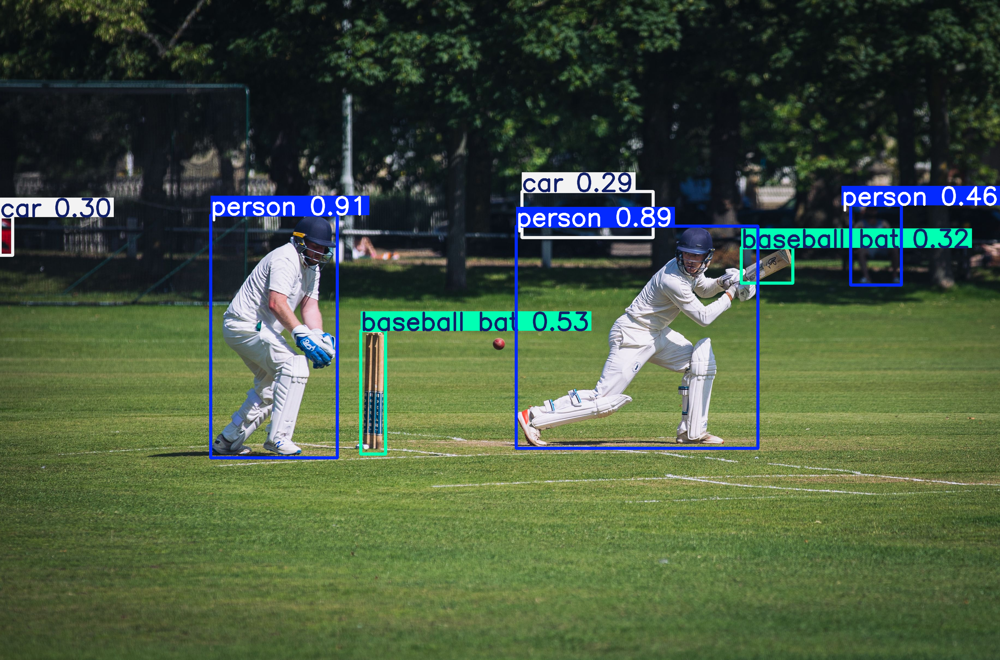

In [4]:
import cv2
from google.colab.patches import cv2_imshow

results = model(img_path)
cv2_imshow(results[0].plot())

In [ ]:
r = results[0]
players = 0
for box in r.boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    if cls == 0 and conf > 0.4:
        players += 1
        print(f"Player {players}: confidence {conf:.2f}, box {int(x1)},{int(y1)},{int(x2)},{int(y2)}")

print("Total players detected:", players)

In [6]:
from google.colab import files
vid = files.upload()
vid_path = list(vid.keys())[0]
print("Uploaded:", vid_path)

Saving 14395637_3840_2160_100fps (1).avi to 14395637_3840_2160_100fps (1).avi
Uploaded: 14395637_3840_2160_100fps (1).avi


In [7]:
model.track(source=vid_path, classes=[0, 32], conf=0.4, save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/300) /content/14395637_3840_2160_100fps (1).avi: 384x640 1 person, 82.7ms
video 1/1 (frame 2/300) /content/14395637_3840_2160_100fps (1).avi: 384x640 1 person, 12.4ms
video 1/1 (frame 3/300) /content/14395637_3840_2160_100fps (1).avi: 384x640 1 person, 12.1ms
video 1/1 (frame 4/300) /content/14395637_3840_2160_100fps (1).avi: 384x640 1 person, 13.5ms
video 1/1 (frame 5/300) /content/14395637_3840_2160_100fps (1).avi: 384x640 1 person, 1

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 

In [8]:
from ultralytics import YOLO
model = YOLO("yolo11n.pt")

In [9]:
results = model.track(source=vid_path, classes=[0, 32], conf=0.4, imgsz=640, vid_stride=3, save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/100) /content/14395637_3840_2160_100fps (1).avi: 384x640 1 person, 11.0ms
video 1/1 (frame 2/100) /content/14395637_3840_2160_100fps (1).avi: 384x640 1 person, 12.9ms
video 1/1 (frame 3/100) /content/14395637_3840_2160_100fps (1).avi: 384x640 1 person, 12.7ms
video 1/1 (frame 4/100) /content/14395637_3840_2160_100fps (1).avi: 384x640 1 person, 16.5ms
video 1/1 (frame 5/100) /content/14395637_3840_2160_100fps (1).avi: 384x640 1 person, 1

In [10]:
!find runs -name "*.avi"

runs/detect/predict-2/14395637_3840_2160_100fps (1).avi
runs/detect/track-2/14395637_3840_2160_100fps (1).avi
runs/detect/track/14395637_3840_2160_100fps (1).avi
runs/detect/predict/14395637_3840_2160_100fps.avi


In [1]:
!ffmpeg -y -i "runs/detect/track/14395637_3840_2160_100fps (1).avi" -vcodec libx264 -pix_fmt yuv420p output.mp4

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

In [2]:
from google.colab import files
files.download("output.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import numpy as np
from ultralytics import YOLO
from google.colab import files

model = YOLO("yolo11n.pt")

vid = files.upload()          # choose the ORIGINAL clip (the .mp4 from Pexels)
vid_path = list(vid.keys())[0]
print("Using:", vid_path)

counts = []
ids = set()
for r in model.track(source=vid_path, classes=[0], conf=0.4, imgsz=640,
                     vid_stride=3, stream=True, verbose=False):
    counts.append(len(r.boxes))
    if r.boxes.id is not None:
        ids.update(r.boxes.id.int().tolist())

print("Frames processed:", len(counts))
print("Average players per frame:", round(float(np.mean(counts)), 2))
print("Maximum players in one frame:", max(counts))
print("Unique player IDs tracked:", len(ids))

Saving 14395637_3840_2160_100fps.mp4 to 14395637_3840_2160_100fps (2).mp4
Using: 14395637_3840_2160_100fps (2).mp4
Frames processed: 300
Average players per frame: 1.6
Maximum players in one frame: 2
Unique player IDs tracked: 5
